# 04 — BSI and NDVI Calibration EDA
## Sentinel-2 Brownfield Detection — Stoke-on-Trent

### Objectives
1. Load the real Stoke-on-Trent Sentinel-2 band array and apply SCL filtering
2. Compute BSI and NDVI across all valid pixels
3. Visualise BSI and NDVI as 2D heatmaps over the Stoke area
4. Extract BSI and NDVI values at the 218 known brownfield register site locations
5. Analyse the distribution of BSI and NDVI values at known brownfield pixels
6. Identify calibrated threshold values for BSI and NDVI to use in the pipeline

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib
import rasterio
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loading_satellite import load_bands, load_scl, bands_20m, bands_10m
from src.scl_filtering import mask_nodata
from src.preprocess import compute_bsi, compute_ndvi, normalise_band_array
from src.coordinate_conversion_pixel import convert_bng_to_utm, utm_coordinate_to_pixel

safe_path = str(PROJECT_ROOT / "raw_data" / "S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE" / "S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE")
print(safe_path)

C:\Users\lward\workspace\sentinel2-brownfield-stoke\raw_data\S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE\S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE


## Section 1 — Data Loading
The Sentinel-2 SAFE folder is loaded using `data_loading_satellite.load_bands` and `load_scl`, returning the full 10-band array and the Scene Classification Layer. `mask_nodata` is then applied to remove nodata and defective pixels, returning the filtered band array, the boolean mask used, and the original 2D shape needed to reconstruct the image for visualisation.

In [9]:
band_array = load_bands(safe_path)
scl_array = load_scl(safe_path)
masked_array, mask, original_shape = mask_nodata(band_array, scl_array)
print(f"Band array shape: {band_array.shape}")
print(f"Masked array shape: {masked_array.shape}")
print(f"Original shape: {original_shape}")
print(f"Valid pixels: {masked_array.shape[0]:,}")

Band array shape: (30140100, 10)
Masked array shape: (21223650, 10)
Original shape: (5490, 5490)
Valid pixels: 21,223,650


## Section 2 — Initial BSI and NDVI Computation
BSI and NDVI are computed across all valid pixels using the raw digital number values. The ranges confirm these significantly exceed the theoretical -1 to 1 boundary, confirming that the raw band values are stored as scaled integers rather than reflectance values. Normalisation by dividing by 10,000 is required before the indices can be correctly interpreted.

In [10]:
bsi_array = compute_bsi(masked_array, bands_20m, bands_10m)
ndvi_array = compute_ndvi(masked_array, bands_20m, bands_10m)
print(f"BSI shape: {bsi_array.shape}")
print(f"NDVI shape: {ndvi_array.shape}")
print(f"BSI range: {bsi_array.min():.4f} to {bsi_array.max():.4f}")
print(f"NDVI range: {ndvi_array.min():.4f} to {ndvi_array.max():.4f}")

BSI shape: (21223650,)
NDVI shape: (21223650,)
BSI range: 0.0000 to 475.6015
NDVI range: 0.0000 to 136.4549


## Section 3 — Band Array Normalisation
Sentinel-2 L2A band values are stored as raw digital numbers scaled by 10,000. Dividing by 10,000 converts these to surface reflectance values, bringing BSI and NDVI into their correct theoretical range of -1 to 1. The band array dtype of uint16 and maximum value of 26,913 confirm this scaling factor. BSI and NDVI are recomputed using the normalised array.

In [11]:
print(f"Band array dtype: {band_array.dtype}")
print(f"Band array min: {band_array.min()}")
print(f"Band array max: {band_array.max()}")

normalised_array = normalise_band_array(masked_array)
bsi_array = compute_bsi(normalised_array, bands_20m, bands_10m)
ndvi_array = compute_ndvi(normalised_array, bands_20m, bands_10m)
print(f"BSI range: {bsi_array.min():.4f} to {bsi_array.max():.4f}")
print(f"NDVI range: {ndvi_array.min():.4f} to {ndvi_array.max():.4f}")

Band array dtype: uint16
Band array min: 0
Band array max: 26913
BSI range: -0.7404 to 1.0000
NDVI range: -1.0000 to 1.0000


## Section 4 — BSI and NDVI Visualisation
BSI and NDVI are reconstructed into 2D arrays matching the original satellite image dimensions using the boolean mask and original shape. Both indices are displayed as heatmaps side by side. The BSI map uses a reversed red-green colour scale where red indicates high bare soil signal and green indicates vegetation or water. The NDVI map uses a standard red-green scale where green indicates dense vegetation. The two maps are expected to be broadly inversely correlated — high BSI areas should correspond to low NDVI areas and vice versa.

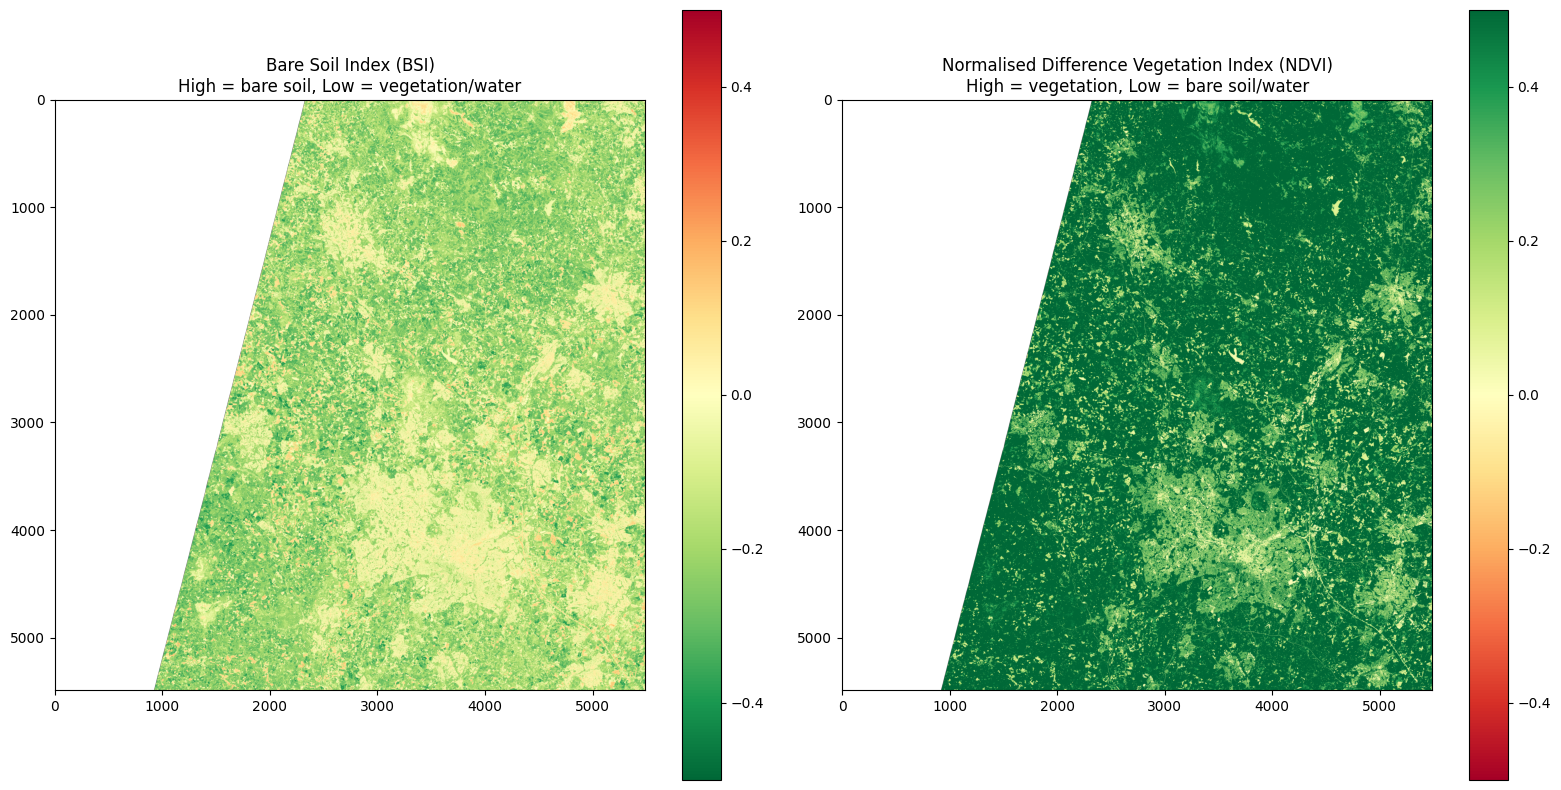

Saved to docs/images/bsi_ndvi_heatmap.png


In [12]:
bsi_2d = np.full(original_shape, np.nan)
ndvi_2d = np.full(original_shape, np.nan)
bsi_2d[mask.reshape(original_shape)] = bsi_array
ndvi_2d[mask.reshape(original_shape)] = ndvi_array

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

im1 = axes[0].imshow(bsi_2d, cmap='RdYlGn_r', vmin=-0.5, vmax=0.5)
axes[0].set_title('Bare Soil Index (BSI)\nHigh = bare soil, Low = vegetation/water')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(ndvi_2d, cmap='RdYlGn', vmin=-0.5, vmax=0.5)
axes[1].set_title('Normalised Difference Vegetation Index (NDVI)\nHigh = vegetation, Low = bare soil/water')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.savefig('../docs/images/bsi_ndvi_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/images/bsi_ndvi_heatmap.png")

## Section 5 — Register Site Extraction
The 2024 Stoke-on-Trent brownfield register is loaded and each site's British National Grid coordinates (GeoX, GeoY) are converted to UTM using `convert_bng_to_utm`, then to pixel positions using `utm_coordinate_to_pixel`. BSI and NDVI values are extracted at each register site's pixel location. Sites that fall outside the satellite tile boundary or were removed by SCL masking are excluded and recorded separately.

In [13]:
import rasterio

band_file = os.path.join(safe_path, "GRANULE")
granule_name = os.listdir(band_file)[0]
r20m_path = os.path.join(band_file, granule_name, "IMG_DATA", "R20m")
sample_band = [f for f in os.listdir(r20m_path) if "_B05_" in f][0]

with rasterio.open(os.path.join(r20m_path, sample_band)) as src:
    bounds = src.bounds
    tile_metadata = {
        "left": bounds.left,
        "top": bounds.top,
        "resolution": 20
    }

register_path = os.path.join(PROJECT_ROOT, "data", "brownfield_register_2024.csv")
df = pd.read_excel(register_path)
print(f"Tile metadata: {tile_metadata}")
print(f"Register sites: {len(df)}")

site_bsi_values = []
site_ndvi_values = []
valid_sites = []
out_of_bounds = []

for idx, row in df.iterrows():
    utm = convert_bng_to_utm(row['GeoX'], row['GeoY'])
    pixel = utm_coordinate_to_pixel(utm['x'], utm['y'], tile_metadata)
    col = pixel['column']
    row_pos = pixel['row']
    
    if 0 <= row_pos < original_shape[0] and 0 <= col < original_shape[1]:
        flat_idx = row_pos * original_shape[1] + col
        if mask[flat_idx]:
            masked_idx = mask[:flat_idx].sum()
            site_bsi_values.append(bsi_array[masked_idx])
            site_ndvi_values.append(ndvi_array[masked_idx])
            valid_sites.append(row['SiteReference'])
        else:
            out_of_bounds.append(row['SiteReference'])
    else:
        out_of_bounds.append(row['SiteReference'])

site_bsi_values = np.array(site_bsi_values)
site_ndvi_values = np.array(site_ndvi_values)

print(f"Sites with valid pixel data: {len(site_bsi_values)}")
print(f"Sites out of bounds or masked: {len(out_of_bounds)}")
print(f"BSI at register sites — min: {site_bsi_values.min():.4f}, max: {site_bsi_values.max():.4f}, mean: {site_bsi_values.mean():.4f}")
print(f"NDVI at register sites — min: {site_ndvi_values.min():.4f}, max: {site_ndvi_values.max():.4f}, mean: {site_ndvi_values.mean():.4f}")

Tile metadata: {'left': 499980.0, 'top': 5900040.0, 'resolution': 20}
Register sites: 218
Sites with valid pixel data: 217
Sites out of bounds or masked: 1
BSI at register sites — min: -0.2647, max: 0.1696, mean: 0.0053
NDVI at register sites — min: 0.0219, max: 0.6416, mean: 0.2118


## Section 6 — BSI and NDVI Distribution at Register Sites
The distribution of BSI and NDVI values across the 217 valid register sites is plotted as histograms. This reveals the spectral characteristics of known brownfield land at the time of the May 2026 image, which is used to inform threshold calibration for the pipeline.

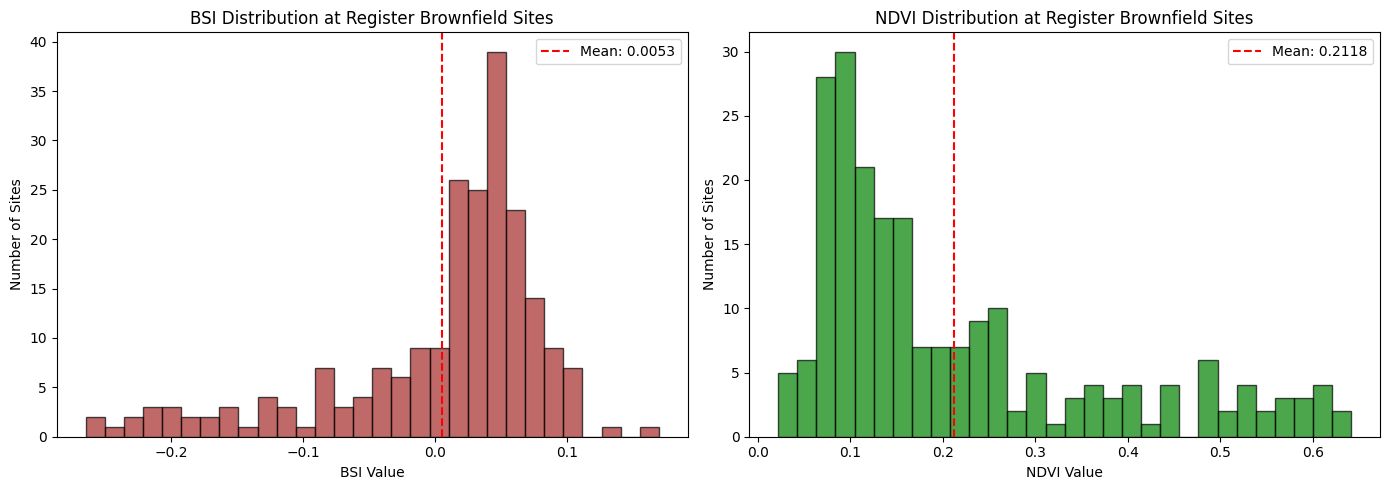

Saved to docs/images/bsi_ndvi_distribution.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(site_bsi_values, bins=30, color='brown', edgecolor='black', alpha=0.7)
axes[0].axvline(site_bsi_values.mean(), color='red', linestyle='--', label=f'Mean: {site_bsi_values.mean():.4f}')
axes[0].set_title('BSI Distribution at Register Brownfield Sites')
axes[0].set_xlabel('BSI Value')
axes[0].set_ylabel('Number of Sites')
axes[0].legend()

axes[1].hist(site_ndvi_values, bins=30, color='green', edgecolor='black', alpha=0.7)
axes[1].axvline(site_ndvi_values.mean(), color='red', linestyle='--', label=f'Mean: {site_ndvi_values.mean():.4f}')
axes[1].set_title('NDVI Distribution at Register Brownfield Sites')
axes[1].set_xlabel('NDVI Value')
axes[1].set_ylabel('Number of Sites')
axes[1].legend()

plt.tight_layout()
plt.savefig('../docs/images/bsi_ndvi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to docs/images/bsi_ndvi_distribution.png")

## Finding — BSI and NDVI Calibration Results

BSI and NDVI were computed across all 21,223,650 valid pixels of the Stoke-on-Trent Sentinel-2 image captured on 25 May 2026. Band values were confirmed as raw digital numbers requiring normalisation by dividing by 10,000 to produce surface reflectance values within the theoretical -1 to 1 range.

BSI and NDVI values were extracted at 217 of the 218 registered brownfield site locations (1 site fell outside the satellite tile boundary). The results reveal a critical finding for calibration:

- BSI at register sites: range -0.26 to 0.17, mean 0.005
- NDVI at register sites: range 0.02 to 0.64, mean 0.21

Registered brownfield sites do not exhibit the high BSI and low NDVI values expected of bare soil. The mean BSI of 0.005 and mean NDVI of 0.21 indicate that registered brownfield land in Stoke-on-Trent is predominantly vegetated at the time of this image. This is consistent with the nature of the brownfield register — it records planning-designated previously developed land, not necessarily currently bare land.

This finding has two important implications for the pipeline design:

First, BSI and NDVI cannot be used as standalone threshold-based detectors for brownfield land. A pixel-level threshold approach would fail to identify most register sites and would produce unreliable candidate detection.

Second, the multi-band PCA approach is validated as the correct primary detection method, as it captures the full spectral signature of urban brownfield land across all 10 bands rather than relying on a single index. BSI and NDVI are retained as additional spectral features to feed into PCA rather than as primary filters.

The visual heatmaps confirm that BSI and NDVI are inversely correlated across the image as expected, demonstrating that both indices are functioning correctly on the normalised band data.